# RQ3 — Resolver Identity

> *Who resolves these conflicts — the coding agent itself or a human
> collaborator?* — PLAN.md §3 (RQ3)

Two levels of analysis per PLAN.md §5.6 / §5.7:

1. **Merge level.** Distribution of `resolver_type` over all internal
   merge commits that produced a conflict.

Figures are saved to `analysis/figures/` as `.pdf` + `.png`.


In [1]:
# Ensure the project root is on sys.path so ``analysis.common`` imports
# cleanly whether the kernel was launched from the repo root or from
# inside analysis/.
import sys
from pathlib import Path

_here = Path.cwd()
for candidate in [_here, *_here.parents]:
    if (candidate / "analysis" / "common.py").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from analysis.common import (
    load_tables,
    build_chunk_frame, build_merge_frame, build_pr_frame,
    setup_style, save_fig,
    stratify, stratum_order,
    descriptive_table, strategy_distribution,
    STRATEGY_ORDER, STRATEGY_PALETTE,
    RESOLVER_ORDER, RESOLVER_PALETTE, RESOLVER_HATCH,
    PR_OUTCOME_ORDER, PR_OUTCOME_PALETTE, PR_OUTCOME_HATCH,
    TOP_N_LANGUAGES,
)

setup_style()
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)


## 1. Load data & build analysis frames

In [2]:
tables = load_tables()
merges = build_merge_frame(tables)
prs    = build_pr_frame(tables)

failed_merges = merges[merges["has_conflict"]].copy() if not merges.empty else merges
print(f"Internal merges (total):     {len(merges):,}")
print(f"Internal merges w/ conflict: {len(failed_merges):,}")
print(f"Universe PRs:                {len(prs):,}")


Internal merges (total):     50,700
Internal merges w/ conflict: 14,960
Universe PRs:                210,902


## 2. Merge-level resolver distribution (global)

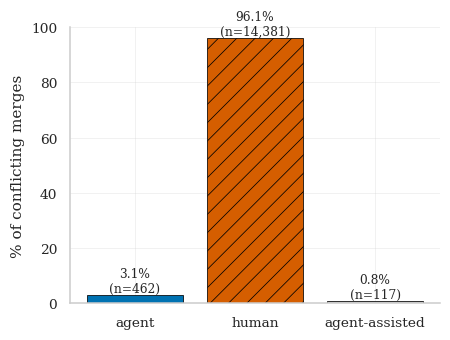

In [3]:
if not failed_merges.empty and "resolver_type" in failed_merges.columns:
    counts = failed_merges["resolver_type"].value_counts()
    counts = counts.reindex(RESOLVER_ORDER + [c for c in counts.index if c not in RESOLVER_ORDER])
    pct = counts / counts.sum() * 100

    fig, ax = plt.subplots(figsize=(4.2, 3.2))
    bars = ax.bar(
        counts.index.astype(str),
        pct.values,
        color=[RESOLVER_PALETTE.get(c, "#BFBFBF") for c in counts.index.astype(str)],
        edgecolor="black", linewidth=0.5,
    )
    for bar, label in zip(bars, counts.index.astype(str)):
        bar.set_hatch(RESOLVER_HATCH.get(label, ""))
    for b, n, p in zip(bars, counts.values, pct.values):
        ax.text(b.get_x() + b.get_width()/2, p + 1,
                f"{p:.1f}%\n(n={n:,})", ha="center", fontsize=8)
    ax.set_ylim(0, min(100, pct.max() + 15))
    ax.set_ylabel("% of conflicting merges")
    save_fig(fig, "rq3_resolver_global")
    plt.show()
else:
    print("No conflicting merges yet or 'resolver_type' missing.")


## 3. Figure — Merge-level resolver distribution by agent

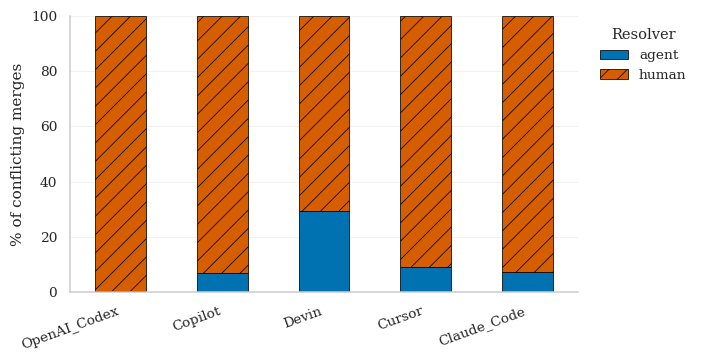


Counts:
resolver_type  agent  human
agent                      
OpenAI_Codex      61  11568
Copilot          122   1684
Devin            224    537
Cursor            43    437
Claude_Code       12    155


In [4]:
if not failed_merges.empty and {"agent", "resolver_type"}.issubset(failed_merges.columns):
    agent_order = stratum_order(failed_merges, "agent")
    matrix = (
        failed_merges
        .groupby("agent")["resolver_type"]
        .value_counts()
        .unstack(fill_value=0)
        .reindex(index=agent_order, columns=RESOLVER_ORDER, fill_value=0)
    )
    pct = matrix.div(matrix.sum(axis=1).replace(0, np.nan), axis=0) * 100

    fig, ax = plt.subplots(figsize=(max(5, 0.9 * len(matrix) + 2), 3.4))
    pct.plot(
        kind="bar", stacked=True,
        color=[RESOLVER_PALETTE[c] for c in RESOLVER_ORDER],
        edgecolor="black", linewidth=0.5, ax=ax,
    )
    for container, label in zip(ax.containers, RESOLVER_ORDER):
        h = RESOLVER_HATCH.get(label, "")
        for p in container.patches:
            p.set_hatch(h)
    ax.set_ylabel("% of conflicting merges")
    ax.set_xlabel("")
    ax.set_ylim(0, 100)
    ax.legend(title="Resolver", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
    save_fig(fig, "rq3_resolver_by_agent")
    plt.show()
    print("\nCounts:")
    print(matrix.to_string())


## 4. Figure — Merge-level resolver distribution by language

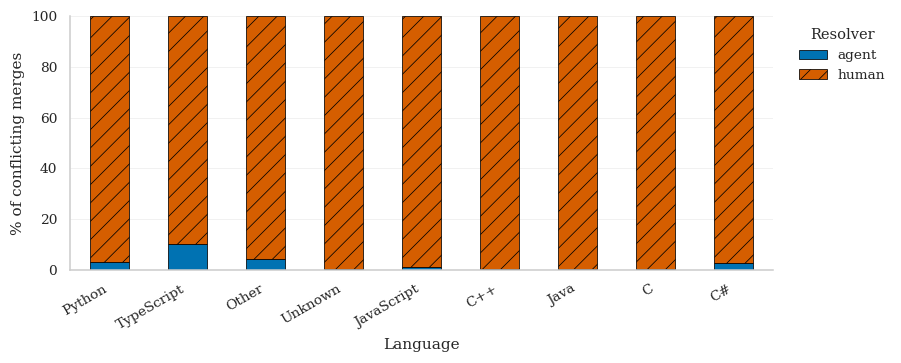

In [5]:
if not failed_merges.empty and {"language_top", "resolver_type"}.issubset(failed_merges.columns):
    lang_order = stratum_order(failed_merges, "language")
    matrix = (
        failed_merges
        .groupby("language_top")["resolver_type"]
        .value_counts()
        .unstack(fill_value=0)
        .reindex(index=lang_order, columns=RESOLVER_ORDER, fill_value=0)
    )
    pct = matrix.div(matrix.sum(axis=1).replace(0, np.nan), axis=0) * 100

    fig, ax = plt.subplots(figsize=(max(6, 0.7 * len(matrix) + 2), 3.4))
    pct.plot(
        kind="bar", stacked=True,
        color=[RESOLVER_PALETTE[c] for c in RESOLVER_ORDER],
        edgecolor="black", linewidth=0.5, ax=ax,
    )
    for container, label in zip(ax.containers, RESOLVER_ORDER):
        h = RESOLVER_HATCH.get(label, "")
        for p in container.patches:
            p.set_hatch(h)
    ax.set_ylabel("% of conflicting merges")
    ax.set_xlabel("Language")
    ax.set_ylim(0, 100)
    ax.legend(title="Resolver", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    save_fig(fig, "rq3_resolver_by_language")
    plt.show()


## 5. Numerical tables for the paper

In [6]:
if not failed_merges.empty and "resolver_type" in failed_merges.columns:
    for axis in ("agent", "language_top", "pr_task_type"):
        if axis not in failed_merges.columns:
            continue
        table = (
            failed_merges.groupby(axis)["resolver_type"]
            .value_counts(normalize=True).mul(100)
            .unstack(fill_value=0).round(2)
        )
        table["n"] = failed_merges.groupby(axis).size()
        table = table.sort_values("n", ascending=False)
        print(f"\n=== Resolver % by {axis} (conflicting merges) ===")
        print(table.to_string())



=== Resolver % by agent (conflicting merges) ===
resolver_type  agent  agent-assisted  human      n
agent                                             
OpenAI_Codex    0.52            0.47  99.01  11684
Copilot         6.74            0.17  93.09   1809
Devin          29.36            0.26  70.38    763
Cursor          8.88            0.83  90.29    484
Claude_Code     5.45           24.09  70.45    220

=== Resolver % by language_top (conflicting merges) ===
resolver_type  agent  agent-assisted  human     n
language_top                                     
Python          2.87            0.59  96.55  2722
TypeScript      9.84            2.86  87.30  2378
Other           4.30            1.00  94.71  2305
Unknown         0.27            0.11  99.62  1858
JavaScript      1.24            0.43  98.33  1619
C++             0.13            0.00  99.87  1537
Java            0.31            0.00  99.69   972
C               0.42            0.00  99.58   943
C#              2.72            0.16

---
### Outputs summary

Figures saved to `analysis/figures/`:

| File stem                         | Paper role |
|-----------------------------------|------------|
| `rq3_resolver_global`             | Headline: who resolves conflicts |
| `rq3_resolver_by_agent`           | Merge-level stratified by agent |
| `rq3_resolver_by_language`        | Merge-level stratified by language |
